In [1]:
from cosipy import BinnedData, UnBinnedData#, COSILike
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.response.PointSourceResponse import PointSourceResponse

from COSILikeNew import COSILike

from scoords import SpacecraftFrame

import astropy.units as u
from astropy.coordinates import SkyCoord, Galactic

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cycler
from scipy.optimize import curve_fit, minimize
import pandas as pd
from lmfit import Model
from lmfit.models import GaussianModel

from threeML import Line, Gaussian, Cauchy, PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter
from histpy import Histogram, Axes, Axis, HealpixAxis
from tqdm import tqdm

from pathlib import Path

import os

# Matplotlib style template
## For black, set #000000. For navy, set #002060
defaultcolor = '#002060'
plt.rcParams.update({'text.color': defaultcolor, 'axes.labelcolor': defaultcolor, 
                     'xtick.color': defaultcolor, 'ytick.color': defaultcolor,
                     'axes.prop_cycle': cycler(color=['b', 'r', 'limegreen']),
                     'font.family':'serif', 'font.serif': 'Times New Roman',
                     'font.size': 22, 'lines.linewidth': 3,
                     'figure.figsize': (9.6, 5.4), 'figure.dpi': 100})

19:28:39 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=244955;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=651867;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=588122;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=419453;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=702127;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=286649;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

/Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=180386;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=40936;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

19:28:40 WARNING   No fermitools installed                                              ]8;id=46023;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=146502;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=283070;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=953248;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=367989;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=730903;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=106992;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=570226;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

In [2]:
# Data directory
DATA_DIR = Path('/Users/penguin/Documents/Research/COSI/COSIpy/docs/DC3/')

# Source name
name = 'CasAfullyresolved'

# define the target coordinates (Cas A)
target_coord = SkyCoord.from_name('Cas A').galactic

In [3]:
# To extract binned data

bg = BinnedData("inputs.yaml")

In [4]:
# WIDE ENERGY BIN
bg.data_file = str(DATA_DIR / 'data/backgrounds/unbinned/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits')
bg.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
bg_filename = DATA_DIR / f'data/backgrounds/binned/albedo_photons_{int(bg.energy_bins[0])}-{int(bg.energy_bins[-1])}keV'

if bg_filename.with_suffix('.hdf5').is_file():
    bg.load_binned_data_from_hdf5(bg_filename.with_suffix('.hdf5'))
else:
    bg.get_binned_data(unbinned_data = bg.data_file, output_name = bg_filename)

In [5]:
# To extract binned data
src = BinnedData("inputs.yaml")

In [6]:
# WIDE ENERGY BIN
src.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
src.time_bins = 86400*93       # Specifies size of time bin to full 3 month width
src_filename = DATA_DIR / f'44Ti/sources/{name}_{int(src.energy_bins[0])}-{int(src.energy_bins[-1])}keV'

if src_filename.with_suffix('.hdf5').is_file():
    src.load_binned_data_from_hdf5(src_filename.with_suffix('.hdf5'))
else:
    src.get_binned_data(unbinned_data = src.data_file, output_name = src_filename)

In [7]:
ori_path = DATA_DIR / 'data/orientation/DC3_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori'
response_path = DATA_DIR / 'data/responses/Response44Ti.o4.e1154_1160.s9607532021290.m1215.filtered.nonsparse.binnedimaging.imagingresponse_nside16.area.h5'
ori_SAA = SpacecraftFile.parse_from_file(ori_path)

In [8]:
scatt_map_SAA = ori_SAA.get_scatt_map(nside = 16, coordsys = 'galactic', target_coord = target_coord)

In [9]:
hist_SAA = Histogram.open('psr_scatt_SAA_hist_DC3.h5')

new_axes = []

for axis in hist_SAA.axes[:2]:
    new_axes += [Axis(np.array(src.energy_bins) * u.keV,
                    label = axis.label,
                    scale = axis.axis_scale)]

axis = hist_SAA.axes[2]
new_axes += [Axis(axis.edges, label = axis.label,
                  scale = axis.axis_scale)]

axis = hist_SAA.axes[3]
new_axes += [HealpixAxis(edges=np.array(axis),
                         nside=axis.nside,
                         label=axis.label,
                         scheme=axis.scheme,
                         coordsys=axis.coordsys)]

In [10]:
psr_SAA = PointSourceResponse(new_axes,
                              contents=hist_SAA.contents,
                              sparse=hist_SAA._sparse,
                              unit=hist_SAA.unit)

In [11]:
# Set background parameter, which is used to fit the amplitude of the background
# For now, this is just a normalization parameter
bkg_par = Parameter("background_cosi",                                         # background parameter
                     2.4,                                                        # initial value of parameter
                     min_value = 0,                                              # minimum value of parameter
                     max_value = 5,                                              # maximum value of parameter
                     delta = 0.05,                                               # initial step used by fitting engine
                     free = True,
                     desc = "Background parameter for cosi")

# Create COSI 3ML plug-in - COSILike (defined in cosipy)
data = src.binned_data.project('Em', 'Phi', 'PsiChi') + bg.binned_data.project('Em', 'Phi', 'PsiChi')

cosi = COSILike("cosi",                                                        # COSI 3ML plugin
                 dr = response_path,                                           # detector response
                 data = data,        # data (source+background)
                #  bkg = Histogram(hist_SAA.axes),                               # background model (zero)
                 bkg = bg.binned_data.project('Em', 'Phi', 'PsiChi'),         # background model 
                #  nuisance_param = bkg_par,                                     # background parameter
                 sc_orientation = ori_SAA,                              # spacecraft orientation
                 coordsys = 'galactic',
                 precomputed_psr_file = 'psr_scatt_SAA_hist.h5')

In [12]:
F = 3e-4 / u.cm / u.cm / u.s
mu = 1157 * u.keV
sigma = 3.85/2.355 * u.keV

spectrum = Gaussian()
spectrum.F.value = F.value
spectrum.F.min_value = F.value / 1e3
spectrum.F.max_value = F.value * 1e3
spectrum.F.unit = F.unit
spectrum.mu.value = mu.value 
spectrum.mu.min_value = mu.value - 10
spectrum.mu.max_value = mu.value + 10
spectrum.mu.unit = mu.unit
spectrum.sigma.value = sigma.value
spectrum.sigma.min_value = 0
spectrum.sigma.max_value = sigma.value + 5
spectrum.sigma.unit = sigma.unit

spectrum.F.free = True
spectrum.mu.free = True
spectrum.sigma.free = True

# Generate some data for plotting
x_data = np.linspace(src.energy_bins[0], src.energy_bins[-1], 400)
y_data = spectrum(x_data)

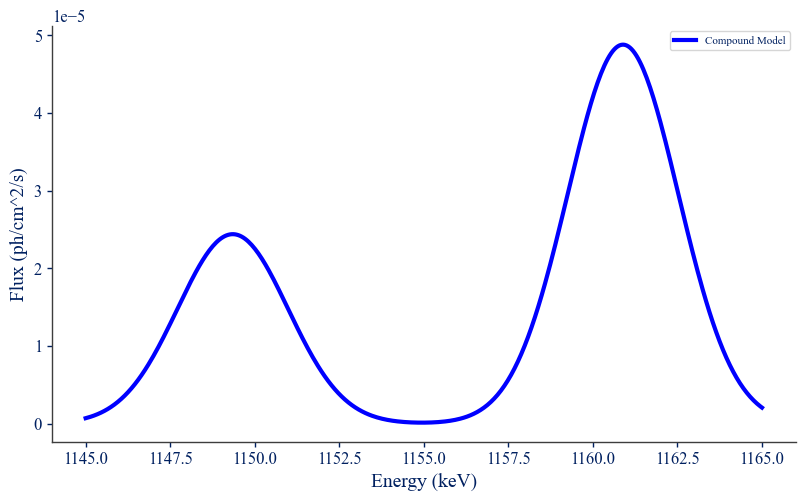

In [13]:
if name != 'CasAsymmetric':
       # Input .source values
       F1 = 1e-4 / u.cm / u.cm / u.s
       # mu1 = (1157-7.65) * u.keV
       # sigma1 = np.sqrt(3.85**2 + 5.3**2) * u.keV / 2.355
       mu1 = {'CasAfullyresolved': 1149.35, 
              'CasApartiallyresolved': 1152.41, 
              'CasAunresolved': 1153.17}
       mu1 = mu1[name] * u.keV
       sigma1 = 3.85 * u.keV / 2.355

       F2 = 2 * F1
       # mu2 = (1157+3.89) * u.keV
       mu2 = {'CasAfullyresolved': 1160.89, 
              'CasApartiallyresolved': 1159.34, 
              'CasAunresolved': 1158.95}
       mu2 = mu2[name] * u.keV
       sigma2 = sigma1

       # Define the first Gaussian
       gaussian1 = Gaussian()
       gaussian1.F.value = F1.value
       gaussian1.F.min_value = F1.value / 1e2
       gaussian1.F.max_value = F1.value * 1e2
       gaussian1.F.unit = F1.unit
       gaussian1.mu.value = mu1.value
       gaussian1.mu.min_value = mu1.value - 10
       gaussian1.mu.max_value = mu1.value + 10
       gaussian1.mu.unit = mu1.unit
       gaussian1.sigma.value = sigma1.value
       gaussian1.sigma.min_value = sigma1.value - 5
       gaussian1.sigma.max_value = sigma1.value + 5
       gaussian1.sigma.unit = sigma1.unit

       # Define the second Gaussian
       gaussian2 = Gaussian()
       gaussian2.F.value = F2.value
       gaussian2.F.min_value = F2.value / 1e2
       gaussian2.F.max_value = F2.value * 1e2
       gaussian2.F.unit = F2.unit
       gaussian2.mu.value = mu2.value
       gaussian2.mu.min_value = mu2.value - 10
       gaussian2.mu.max_value = mu2.value + 10
       gaussian2.mu.unit = mu2.unit
       gaussian2.sigma.value = sigma2.value
       gaussian2.sigma.min_value = sigma2.value - 5
       gaussian2.sigma.max_value = sigma2.value + 5
       gaussian2.sigma.unit = sigma2.unit

       gaussian1.F.free = True
       gaussian1.mu.free = True
       gaussian1.sigma.free = False
       gaussian2.F.free = True
       gaussian2.mu.free = True
       gaussian2.sigma.free = False

       # Create the compound model
       spectrum = gaussian1 + gaussian2

       # Generate some data for plotting
       x_data = np.linspace(src.energy_bins[0], src.energy_bins[-1], 400)
       y_data = spectrum(x_data)

       # Plot the compound model
       plt.plot(x_data, y_data, label="Compound Model")
       plt.xlabel("Energy (keV)")
       plt.ylabel("Flux (ph/cm^2/s)")
       plt.legend()
       plt.show()

In [14]:
CasA_astromodel = PointSource('CasA', spectral_shape=spectrum, 
                           l=target_coord.l.value,
                           b=target_coord.b.value)

Model_astromodel = Model(CasA_astromodel)

cosi.set_model(Model_astromodel)
plugins = DataList(cosi)        # 'cosi': COSI's 3ML plugin. If there are multiple instruments, we input a list of those instrument plugins here
like = JointLikelihood(Model_astromodel, plugins, verbose = False)

19:30:53 INFO      set the minimizer to minuit                                             ]8;id=614862;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=412993;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

In [15]:
like.fit(quiet=True)

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


19:31:03 WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=388865;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=70945;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   49.82 percent of samples have been thrown away because they failed the  ]8;id=294945;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=821442;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

19:31:03 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.01.    ]8;id=539060;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=737570;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=920761;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=627752;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.02.    ]8;id=116808;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=778127;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=449105;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=151050;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

(                                         value  negative_error  \
 CasA.spectrum.main.composite.F_1      0.009999       -0.000070   
 CasA.spectrum.main.composite.mu_1  1150.776925       -0.012648   
 CasA.spectrum.main.composite.F_2      0.000229       -0.000126   
 CasA.spectrum.main.composite.mu_2  1160.700300       -0.126801   
 
                                    positive_error     error         unit  
 CasA.spectrum.main.composite.F_1        -0.000010  0.000030  1 / (s cm2)  
 CasA.spectrum.main.composite.mu_1        0.148473  0.080561          keV  
 CasA.spectrum.main.composite.F_2         0.000020  0.000073  1 / (s cm2)  
 CasA.spectrum.main.composite.mu_2        0.851973  0.489387          keV  ,
        -log(likelihood)
 cosi       60979.337795
 total      60979.337795)

In [16]:
# Summary of results
results = like.results

parameters = {par.name:results.get_variates(par.path)                           # Exactly as given in https://threeml.readthedocs.io/en/stable/notebooks/Analysis_results_showcase.html#Error-propagation
              for par in results.optimized_model['CasA'].parameters.values()
              if par.free}

results_error_propagator_function = results.propagate(results.optimized_model['CasA'].spectrum.main.shape.evaluate_at, **parameters)

19:31:53 WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.01.    ]8;id=752355;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=993675;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=94767;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=952471;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.02.    ]8;id=778447;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=344314;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=634941;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=189107;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

         WARNING   The current value of the parameter F_1 (1.0) was above the new maximum 0.01.    ]8;id=886604;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=651478;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_1 (0.0) was below the new minimum         ]8;id=90334;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=5300;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1139.35.                                                                                         

         WARNING   The current value of the parameter F_2 (1.0) was above the new maximum 0.02.    ]8;id=626929;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=654679;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#794\794]8;;\

         WARNING   The current value of the parameter mu_2 (0.0) was below the new minimum         ]8;id=939585;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=149546;file:///Users/penguin/miniconda3/envs/cosipy/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\
                  1150.89.                                                                                         

In [17]:
energies = np.linspace(1140, 1180, 113)        # Also taken from https://threeml.readthedocs.io/en/stable/notebooks/Analysis_results_showcase.html#Error-propagation

flux_low = np.zeros_like(energies)
flux_median = np.zeros_like(energies)
flux_high = np.zeros_like(energies)

p = tqdm(total=len(energies), desc='Propagating errors')
# Evaluate flux
for i, e in enumerate(energies):
    this_flux = results_error_propagator_function(e)
    # flux_low[i], flux_high[i] = this_flux.equal_tail_interval(cl=0.68)       # 1-sigma bounds, default (without argument) returns 1-sigma
    # Alternately,
    flux_low[i], flux_high[i] = this_flux.highest_posterior_density_interval(cl=0.68)
    flux_median[i] = this_flux.median

    p.update(1)

Propagating errors:  98%|█████████▊| 111/113 [00:04<00:00, 23.37it/s]

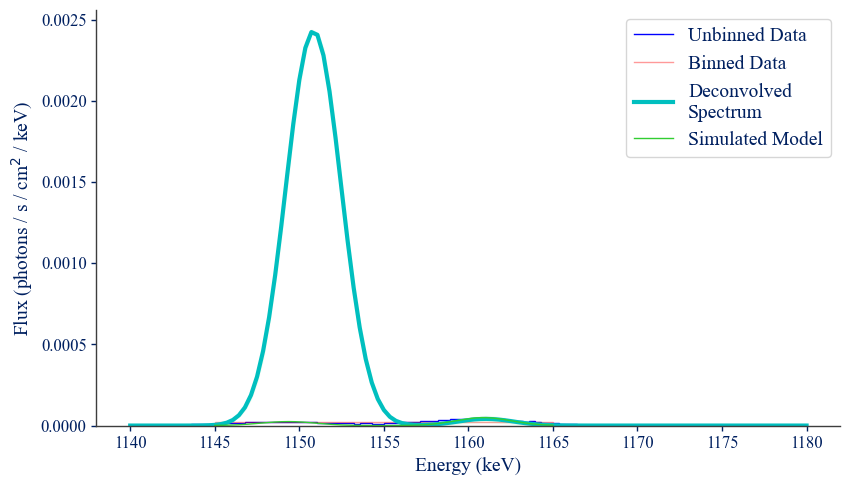

In [20]:
obs_duration = 93 * 86400       # seconds
Aeff = 3                      # cm**2
normalization = 0.7

source = UnBinnedData("inputs.yaml")
source.data_file = str(DATA_DIR / f'44Ti/sources/{name}_3months_unbinned_data_filtered_with_SAAcut.fits')
this_dict = source.get_dict_from_fits(source.data_file)

counts, _ = np.histogram(this_dict['Energies'], bins=energies)
# plt.stairs(counts / counts.sum() / np.diff(energies), energies)
plt.stairs(counts / np.diff(energies) / obs_duration / Aeff * normalization, energies, label='Unbinned Data')     # Plots observed counts / binwidth       (photons / sec / cm**2 / keV)

counts = src.binned_data.project('Em').todense().contents
bins = src.binned_data.axes['Em'].edges.value
plt.stairs(counts / np.diff(bins) / obs_duration / Aeff * normalization, bins, lw=1, alpha=0.4, label='Binned Data')

plt.plot(energies, flux_median, c='c', label='Deconvolved\nSpectrum')      # Plots physical value Flux     (photons / sec / cm**2 / keV)
plt.fill_between(energies, flux_low, flux_high, alpha=0.1, color='lightgreen')

plt.plot(x_data, y_data, lw=1, label="Simulated Model")

plt.ylabel('Flux (photons / s / cm$^{2}$ / keV)')
plt.xlabel('Energy (keV)')
# plt.yscale('log')
plt.legend(fontsize=14)
plt.show()

In [21]:
results.display()

Best fit values:

,result,unit
parameter,,
CasA.spectrum.main.composite.F_1,(10.00 +/- 0.05) x 10^-3,1 / (s cm2)
CasA.spectrum.main.composite.mu_1,(1.15078 +/- 0.00011) x 10^3,keV
CasA.spectrum.main.composite.F_2,(2.3 +/- 1.0) x 10^-4,1 / (s cm2)
CasA.spectrum.main.composite.mu_2,(1.1607 +/- 0.0006) x 10^3,keV


Correlation matrix:

1.00,-0.82,0.74,-0.74
-0.82,1.00,-0.80,0.80
0.74,-0.80,1.00,-0.32
-0.74,0.80,-0.32,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,60979.337795
total,60979.337795


Values of statistical measures:

,statistical measures
AIC,121956.67559
BIC,121958.67559


In [22]:
def spectrum_reset(spec):
    if name == 'CasAsymmetric':
        F = 3e-4 / u.cm / u.cm / u.s
        mu = 1157 * u.keV
        sigma = 3.85/2.355 * u.keV

        spec.F.value = F.value
        spec.F.min_value = F.value / 1e3
        spec.F.max_value = F.value * 1e3
        spec.F.unit = F.unit
        spec.mu.value = mu.value 
        spec.mu.min_value = mu.value - 10
        spec.mu.max_value = mu.value + 10
        spec.mu.unit = mu.unit
        spec.sigma.value = sigma.value
        spec.sigma.min_value = sigma.value - 5
        spec.sigma.max_value = sigma.value + 5
        spec.sigma.unit = sigma.unit

    else:
        # Input .source values
        F1 = 1e-4 / u.cm / u.cm / u.s
        mu1 = {'CasAfullyresolved': 1149.35, 
               'CasApartiallyresolved': 1152.41, 
               'CasAunresolved': 1153.17}
        mu1 = mu1[name] * u.keV
        sigma1 = 3.85 * u.keV / 2.355
 
        F2 = 2 * F1
        mu2 = {'CasAfullyresolved': 1160.89, 
               'CasApartiallyresolved': 1159.34, 
               'CasAunresolved': 1158.95}
        mu2 = mu2[name] * u.keV
        sigma2 = sigma1
 
        # Define the first Gaussian
        spec.F_1.value = F1.value
        spec.F_1.min_value = F1.value / 1e2
        spec.F_1.max_value = F1.value * 1e2
        spec.F_1.unit = F1.unit
        spec.mu_1.value = mu1.value
        spec.mu_1.min_value = mu1.value - 10
        spec.mu_1.max_value = mu1.value + 10
        spec.mu_1.unit = mu1.unit
        spec.sigma_1.value = sigma1.value
        spec.sigma_1.min_value = sigma1.value - 5
        spec.sigma_1.max_value = sigma1.value + 5
        spec.sigma_1.unit = sigma1.unit
 
        # Define the second Gaussian
        spec.F_2.value = F2.value
        spec.F_2.min_value = F2.value / 1e2
        spec.F_2.max_value = F2.value * 1e2
        spec.F_2.unit = F2.unit
        spec.mu_2.value = mu2.value
        spec.mu_2.min_value = mu2.value - 10
        spec.mu_2.max_value = mu2.value + 10
        spec.mu_2.unit = mu2.unit
        spec.sigma_2.value = sigma2.value
        spec.sigma_2.min_value = sigma2.value - 5
        spec.sigma_2.max_value = sigma2.value + 5
        spec.sigma_2.unit = sigma2.unit

    return spec

results_err = results_error_propagator_function

energy = energies

flux_lo = flux_low
flux_hi = flux_high
flux_inj = np.zeros_like(energy)

for i, e in enumerate(energy):
    spectrum_inj = spectrum_reset(spec=spectrum)
    flux_inj[i] = spectrum_inj.evaluate_at(e)

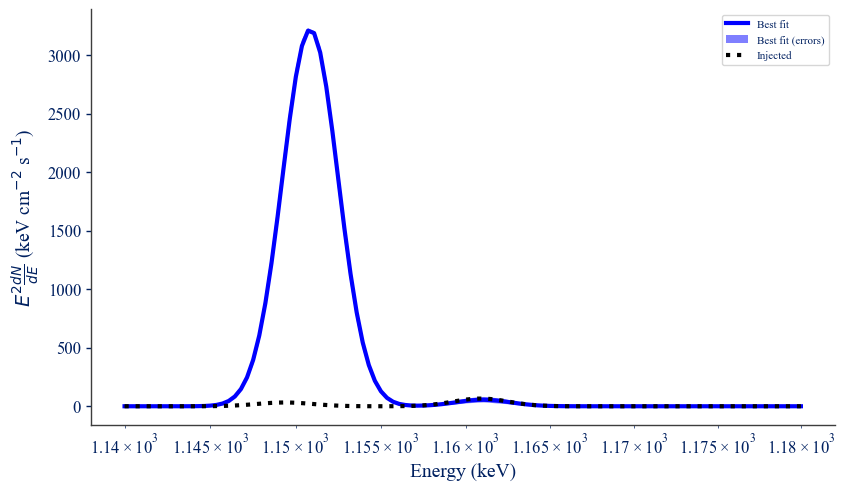

In [23]:
fig,ax = plt.subplots()

plt.plot(energy, energy*energy*flux_median, label = "Best fit")
plt.fill_between(energy, energy*energy*flux_lo, energy*energy*flux_hi, alpha = .5, label = "Best fit (errors)")
plt.plot(energy, energy*energy*flux_inj, color = 'black', ls = ":", label = "Injected")

plt.xscale("log")
# ax.set_yscale("log")

plt.xlabel("Energy (keV)")
plt.ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

plt.legend()
plt.show()

In [24]:
cosi._expected_counts['CasA'].project('Em').contents

<Quantity [17785.95554106]>

In [47]:
src.binned_data.project('Em').contents[0]

17679.0

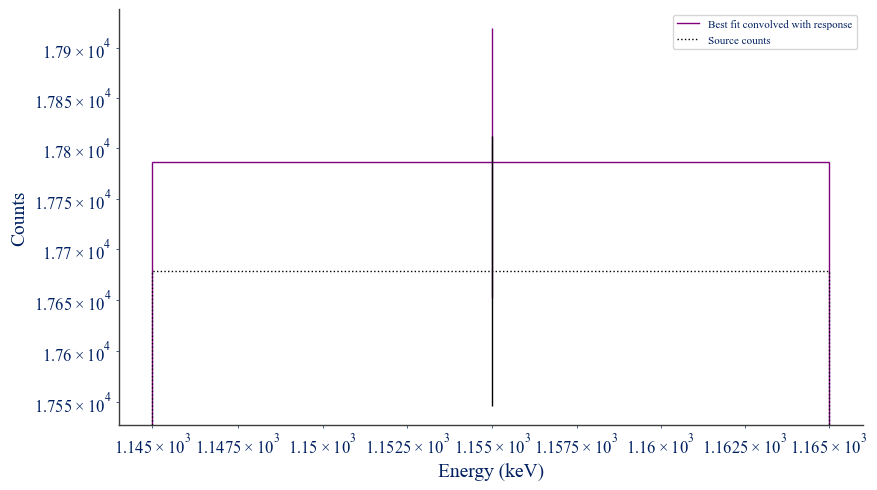

In [42]:
expectation = cosi._expected_counts['CasA']
binned_energy_edges = src.binned_data.axes['Em'].edges.value
binned_energy = np.array([])
binned_energy = np.append(binned_energy, (binned_energy_edges[0] + binned_energy_edges[1]) / 2)

fig,ax = plt.subplots()

ax.stairs(expectation.project('Em').todense().contents, binned_energy_edges, color='purple', label = "Best fit convolved with response")
ax.errorbar(binned_energy, expectation.project('Em').todense().contents, yerr=np.sqrt(expectation.project('Em').todense().contents), color='purple', linewidth=0, elinewidth=1)
ax.stairs(src.binned_data.project('Em').todense().contents, binned_energy_edges, color = 'black', ls = ":", label = "Source counts")
ax.errorbar(binned_energy, src.binned_data.project('Em').todense().contents, yerr=np.sqrt(src.binned_data.project('Em').todense().contents), color='black', linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

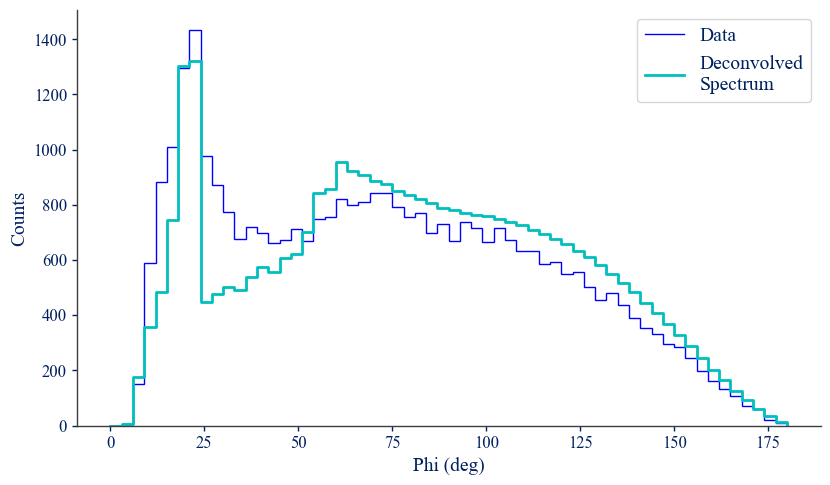

In [ ]:
phis = np.linspace(0, 180, 61)
counts, _ = np.histogram(this_dict['Phi'], bins=np.deg2rad(phis))
ydata = psr_SAA.get_expectation(spectrum).project('Phi')

normalization = np.sum(ydata.contents) / np.sum(counts)

plt.stairs(counts * normalization, phis, lw=1, label='Data')     # Plots observed counts / binwidth       (photons / sec / cm**2 / keV)

# plt.plot(energies, flux_median, c='c', label='Spectrum')      # Plots physical value Flux     (photons / sec / cm**2 / keV)
# plt.fill_between(energies, flux_low, flux_high, alpha=0.1, color='lightgreen')
ydata.plot(ax=plt.gca(), lw=2, c='c', label='Deconvolved\nSpectrum')

plt.ylabel('Counts')
plt.xlabel('Phi (deg)')
# plt.yscale('log')
plt.legend(fontsize=14)
plt.show()

(<Mollview: >, <matplotlib.image.AxesImage at 0x2bffbdc90>)

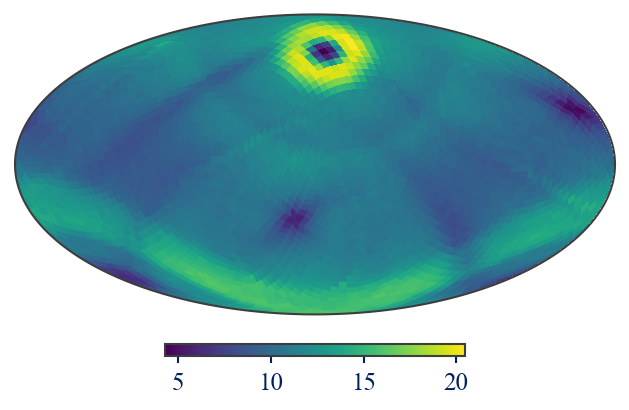

Propagating errors: 100%|██████████| 113/113 [00:24<00:00, 13.89it/s]

In [ ]:
psr_SAA.get_expectation(spectrum).project('PsiChi').plot()